In [2]:
import pandas as pd, numpy as np
import random

# Operaciones con Fecha

### 1. Uso del Módulo `datetime`

#### El módulo `datetime` en la biblioteca estándar de Python proporciona clases para manipular fechas

In [3]:
from datetime import datetime, timedelta

In [3]:
# Fecha y hora actual
now = datetime.now()
print(now)



2024-12-03 02:15:08.043395


In [4]:
print("fecha y hora actual: ", now)

fecha y hora actual:  2024-12-03 02:15:08.043395


In [11]:
# Fecha específica
spec_date = datetime(2024,12,25)
print("fecha especifica: ",spec_date)

fecha especifica:  2024-12-25 00:00:00


In [12]:
# Sumar días a una fecha
future_date = spec_date + timedelta(days=10)
print("fecha futura: ",future_date)

fecha futura:  2025-01-04 00:00:00


In [13]:
# Diferencia entre fechas
diff = spec_date - now
print("diferencia entre fechas: ",diff)

diferencia entre fechas:  21 days, 21:44:51.956605


In [14]:
dir(spec_date)  # directorio del objeto (métodos y atributos en este caso de un objeto tipo datetime)

['__add__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__radd__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rsub__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 'astimezone',
 'combine',
 'ctime',
 'date',
 'day',
 'dst',
 'fold',
 'fromisocalendar',
 'fromisoformat',
 'fromordinal',
 'fromtimestamp',
 'hour',
 'isocalendar',
 'isoformat',
 'isoweekday',
 'max',
 'microsecond',
 'min',
 'minute',
 'month',
 'now',
 'replace',
 'resolution',
 'second',
 'strftime',
 'strptime',
 'time',
 'timestamp',
 'timetuple',
 'timetz',
 'today',
 'toordinal',
 'tzinfo',
 'tzname',
 'utcfromtimestamp',
 'utcnow',
 'utcoffset',
 'utctimetuple',
 'weekday',
 'year']

In [15]:
now.month # este es un atriuto que forma parte de "datetime"

12

In [16]:
now.day

3

# 2.Uso de fechas en `pandas`

In [27]:
# Creando un DataFrame con fechas

df = pd.DataFrame({
    'fecha': ['2021-01-01','2021-01-02','2021-01-03','2021-01-10','2021-01-25','2021-01-30','2021-02-10'
    ,'2021-02-15','2021-02-20'],'valor': [10,20,30,10,10,10,5,5,5]
})
df

,fecha,valor
0,2021-01-01,10
1,2021-01-02,20
2,2021-01-03,30
3,2021-01-10,10
4,2021-01-25,10
5,2021-01-30,10
6,2021-02-10,5
7,2021-02-15,5
8,2021-02-20,5


In [28]:
df.info() #no reconoce la fecha como formato de fecha sino como formato de objeto.
# entonces hay que cambiarlo a formato datetime

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   fecha   9 non-null      object
 1   valor   9 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 272.0+ bytes


In [29]:
# Convirtiendo la columna 'fecha' en datetime
df['fecha'] = pd.to_datetime(df['fecha'])
df

,fecha,valor
0,2021-01-01,10
1,2021-01-02,20
2,2021-01-03,30
3,2021-01-10,10
4,2021-01-25,10
5,2021-01-30,10
6,2021-02-10,5
7,2021-02-15,5
8,2021-02-20,5


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   9 non-null      datetime64[ns]
 1   valor   9 non-null      int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 272.0 bytes


In [31]:
# Ponerlo como índice (útil para operaciones de Series de Tiempo)
df.set_index('fecha', inplace=True)
df

,valor
fecha,
2021-01-01,10
2021-01-02,20
2021-01-03,30
2021-01-10,10
2021-01-25,10
2021-01-30,10
2021-02-10,5
2021-02-15,5
2021-02-20,5


In [32]:
# Re-muestreo (por ejemplo agregando datos mensuales) 'M' signnifica mes. Agrupa mes y suma. Quiero ver los valores por mes (agregados)
df_mensual = df.resample('M').sum()
df_mensual

<ipython-input-32-896779278f67>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensual = df.resample('M').sum()


,valor
fecha,
2021-01-31,90
2021-02-28,15


In [33]:
df.resample('M')

<ipython-input-33-992dd4a07084>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M')


In [34]:
# No queremos que la última fecha por mes sea la del calnedario sino la del registro
# Agrupar por mes y obtener la última observación de cada mes
ultima_por_mes = df.groupby(df.index.to_period('M')).last()
ultima_por_mes

,valor
fecha,
2021-01,10
2021-02,5


# Selecionar fechas de diferentes formas (formatos)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9 entries, 2021-01-01 to 2021-02-20
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   valor   9 non-null      int64
dtypes: int64(1)
memory usage: 144.0 bytes


In [36]:
df.loc["2021-01-01"]

,2021-01-01
valor,10


In [37]:
df.loc["01-01-2021"]

,2021-01-01
valor,10


In [38]:
df.loc["20210101"]

,2021-01-01
valor,10


In [39]:
df.loc["2021/01/01"]

,2021-01-01
valor,10


In [40]:
df.loc[datetime(2021,1,1)]

,2021-01-01
valor,10


In [44]:
df.loc[datetime(2021,1,1):"2021-01-03"]

,valor
fecha,
2021-01-01,10
2021-01-02,20
2021-01-03,30


In [45]:
# Ejercicio rápido
# input como string (cadena)
input_date_str = "07/04/2024" # MM/DD/YYYY 4 de Julio
input_date_str

'07/04/2024'

In [53]:
# vamos a convertir al objeto que esta como cadena en un objeto datetime
date_obj = datetime.strptime(input_date_str, "%m/%d/%Y")
date_obj

datetime.datetime(2024, 7, 4, 0, 0)

In [54]:
# se le puede dar el formato datetime al objeto como se desee
output_date_str = date_obj.strftime("%Y-%m-%d")
output_date_str

'2024-07-04'

In [56]:
print("Fecha original",input_date_str) #cadena
print("Fecha convertida",output_date_str) #cadena pero con el formato requerido
print("Fecha como DateTime", date_obj) # datetime antes de pasarlo a cadena con formato que quiero

Fecha original 07/04/2024
Fecha convertida 2024-07-04
Fecha como DateTime 2024-07-04 00:00:00


In [49]:
date_obj

datetime.datetime(2024, 7, 4, 0, 0)

In [50]:
df=datetime(2024,4,7,0,0)

In [51]:
type(date_obj)

datetime.datetime

In [57]:
date_obj+timedelta(days=20)

datetime.datetime(2024, 7, 24, 0, 0)

# 3. Rango de Fechas y Frecuencias

Generando Rangos de Fechas

In [58]:
# Generar un rango de fechas
# Crear un índice de fechas
rango_fechas = pd.date_range(start="2021-01-01", end="2021-01-10", freq="D")
rango_fechas

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10'],
              dtype='datetime64[ns]', freq='D')

In [59]:
# Convertir a mensual
rango_mensual = rango_fechas.to_period("M")
print(rango_mensual)
# es como extraer el mes y año

PeriodIndex(['2021-01', '2021-01', '2021-01', '2021-01', '2021-01', '2021-01',
             '2021-01', '2021-01', '2021-01', '2021-01'],
            dtype='period[M]')


In [61]:
pd.Series(rango_fechas)

,0
0,2021-01-01
1,2021-01-02
2,2021-01-03
3,2021-01-04
4,2021-01-05
5,2021-01-06
6,2021-01-07
7,2021-01-08
8,2021-01-09
9,2021-01-10


In [63]:
pd.Series(rango_mensual)


,0
0,2021-01
1,2021-01
2,2021-01
3,2021-01
4,2021-01
5,2021-01
6,2021-01
7,2021-01
8,2021-01
9,2021-01


In [65]:
# Se recomienda usar también pd.TimeDelta de pandas
# TimeDelta de 3 días
td=pd.Timedelta(days=3)
td

Timedelta('3 days 00:00:00')

In [67]:
df=pd.DataFrame({
    'fecha':pd.date_range(start='2021//01/01',periods=10,freq='D')
    })
df

,fecha
0,2021-01-01
1,2021-01-02
2,2021-01-03
3,2021-01-04
4,2021-01-05
5,2021-01-06
6,2021-01-07
7,2021-01-08
8,2021-01-09
9,2021-01-10


In [68]:
# Puedes acceder a cualquier elemento
df['fecha'][0].weekday() # viernes, el 0 es lunes

4

## Shifting de fecha (a menudo es útil en series de tiempo)

In [5]:
data={
    'fecha':pd.date_range(start='2021-01-01',periods=5,freq='D'),
    'valor':[1,2,3,4,5]
}

In [6]:
data

{'fecha': DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
                '2021-01-05'],
               dtype='datetime64[ns]', freq='D'),
 'valor': [1, 2, 3, 4, 5]}

In [7]:
df=pd.DataFrame(data)
df

,fecha,valor
0,2021-01-01,1
1,2021-01-02,2
2,2021-01-03,3
3,2021-01-04,4
4,2021-01-05,5


## Operación de Desplazamiento

Desplazando la columna 'valor' hacia abajo (hacia delante en el tiempo) un periodo

In [72]:
# Desplazar la columna 'valor' hacia abajo
df['valor_+1d']=df['valor'].shift(1)
df['valor_+2d']=df['valor'].shift(2)
df['valor_-1d']=df['valor'].shift(-1)
df['valor_-2d']=df['valor'].shift(-2)
df

,fecha,valor,valor_+1d,valor_+2d,valor_-1d,valor_-2d
0,2021-01-01,1,NaN,NaN,2.0,3.0
1,2021-01-02,2,1.0,NaN,3.0,4.0
2,2021-01-03,3,2.0,1.0,4.0,5.0
3,2021-01-04,4,3.0,2.0,5.0,NaN
4,2021-01-05,5,4.0,3.0,NaN,NaN


In [73]:
# una aplicación de esto en series de tiempo, es calcular rendimientos diarios
# NaN no es número. NaT no es Time
# Rendimiento Típico = (Valor Final - Valor inicial) / Valor inicial = (Valor Final / Valor inicial) -1
df['valor']/df['valor_+1d']-1

,0
0,NaN
1,1.000000
2,0.500000
3,0.333333
4,0.250000


In [74]:
df['valor'].pct_change()

,valor
0,NaN
1,1.000000
2,0.500000
3,0.333333
4,0.250000


In [75]:
df['año']=df['fecha'].dt.year
df['mes']=df['fecha'].dt.month
df['dia']=df['fecha'].dt.day
df['dia_semana']=df['fecha'].dt.day_name()
df

,fecha,valor,valor_+1d,valor_+2d,valor_-1d,valor_-2d,año,mes,dia,dia_semana
0,2021-01-01,1,NaN,NaN,2.0,3.0,2021,1,1,Friday
1,2021-01-02,2,1.0,NaN,3.0,4.0,2021,1,2,Saturday
2,2021-01-03,3,2.0,1.0,4.0,5.0,2021,1,3,Sunday
3,2021-01-04,4,3.0,2.0,5.0,NaN,2021,1,4,Monday
4,2021-01-05,5,4.0,3.0,NaN,NaN,2021,1,5,Tuesday


In [1]:
# ejemplo de remuestreo con agregación semanal

In [16]:
suma_semana=df.resample('W').sum()
suma_semana

In [15]:
# Si tuvieran el formato con horas
df=pd.DateFrame({
    'datetime_column':pd.to_datetime(["2021-01-01"])
})
})

In [14]:
# conviertiendo datetime a solo date
df['date_column']=df['datetime_column'].dt.date
df

In [13]:
# Pueden hacer date_range para minutos y horas
pd.date_range(start='2021-01-01',periods=5,freq='H')

C:\Users\kike2\AppData\Local\Temp\ipykernel_14772\1022703194.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start='2021-01-01',periods=5,freq='H')


DatetimeIndex(['2021-01-01 00:00:00', '2021-01-01 01:00:00',
               '2021-01-01 02:00:00', '2021-01-01 03:00:00',
               '2021-01-01 04:00:00'],
              dtype='datetime64[ns]', freq='h')

Current date and time: 2026-08-04 16:16:07.652775
        Date  Value
0 2026-07-06     74
1 2026-07-07     85
2 2026-07-08     64
3 2026-07-09    132
4 2026-07-10     89


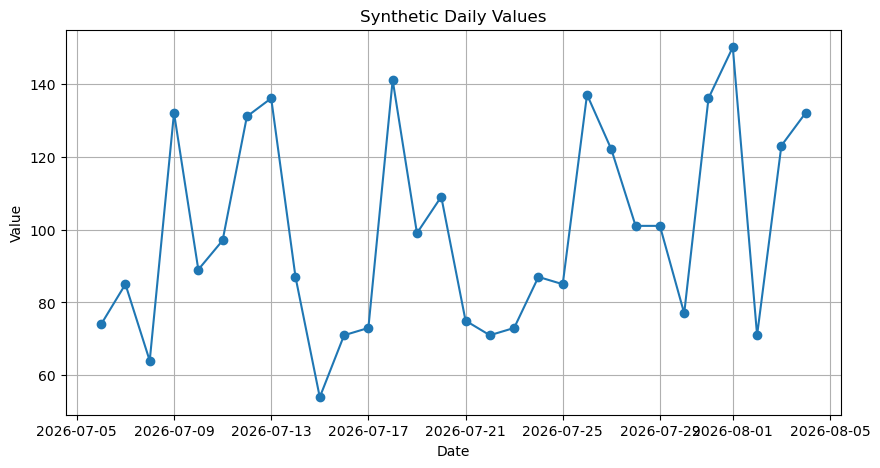

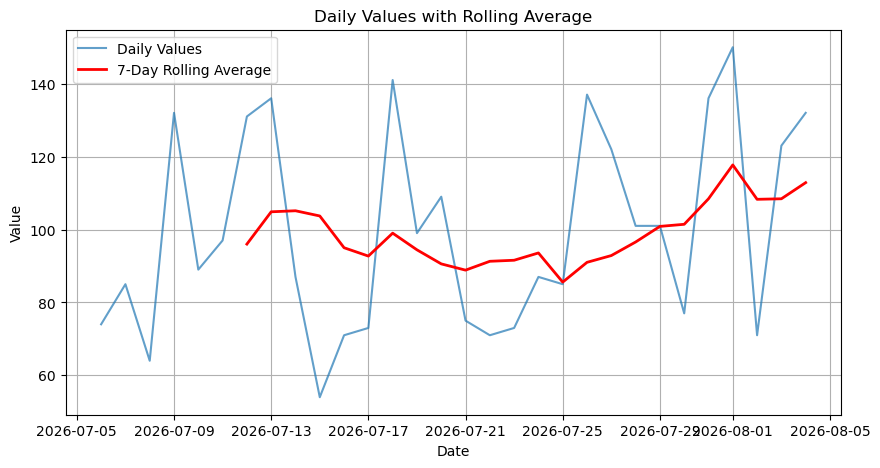


Average values by weekday:
Weekday
Friday        96.25
Monday       112.80
Saturday     118.25
Sunday       109.50
Thursday      88.25
Tuesday       96.00
Wednesday     72.50
Name: Value, dtype: float64

Average values by month:
Month
August    119.000000
July       96.423077
Name: Value, dtype: float64


In [1]:
# Date Operations and Time Series Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

# 1. Current date and time
now = datetime.now()
print("Current date and time:", now)

# 2. Generate synthetic daily data for 30 days
dates = pd.date_range(start=now.date() - timedelta(days=29), end=now.date())
values = [random.randint(50, 150) for _ in range(len(dates))]

df = pd.DataFrame({"Date": dates, "Value": values})
print(df.head())

# 3. Basic time series visualization
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Value"], marker="o")
plt.title("Synthetic Daily Values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.show()

# 4. Rolling average (7-day window)
df["Rolling_Avg"] = df["Value"].rolling(window=7).mean()

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Value"], label="Daily Values", alpha=0.7)
plt.plot(df["Date"], df["Rolling_Avg"], label="7-Day Rolling Average", color="red", linewidth=2)
plt.title("Daily Values with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# 5. Extract weekday and month for analysis
df["Weekday"] = df["Date"].dt.day_name()
df["Month"] = df["Date"].dt.month_name()

print("\nAverage values by weekday:")
print(df.groupby("Weekday")["Value"].mean())

print("\nAverage values by month:")
print(df.groupby("Month")["Value"].mean())
